In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler



In [2]:
# 1. Load the dataset
cars = pd.read_csv('CarPrice_Assignment.csv')

# 2. Data Cleaning & Preparation
# Extract CompanyName from the CarName column
cars['CompanyName'] = cars['CarName'].apply(lambda x: x.split(' ')[0])



In [3]:
# Fix spelling errors in company names
corrections = {
    'maxda': 'mazda', 'Nissan': 'nissan', 'porcshce': 'porsche',
    'toyouta': 'toyota', 'vokswagen': 'volkswagen', 'vw': 'volkswagen'
}
cars['CompanyName'] = cars['CompanyName'].replace(corrections)

# Drop columns not useful for prediction or that were transformed
cars = cars.drop(['car_ID', 'CarName'], axis=1)

# Convert categorical variables to dummy variables
# drop_first=True is crucial to reduce multicollinearity
cars_numeric = pd.get_dummies(cars, drop_first=True)

# 3. Define Features (X) and Target (y)
X = cars_numeric.drop('price', axis=1)
y = cars_numeric['price']



In [4]:
# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

# 5. Feature Scaling
# Scaling puts all features on the same scale (0 to 1), essential for interpreting coefficients correctly
scaler = MinMaxScaler()
num_vars = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 
            'enginesize', 'boreratio', 'stroke', 'compressionratio', 
            'horsepower', 'peakrpm', 'citympg', 'highwaympg']

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])



In [5]:
# 6. Model Building with Feature Selection
lm = LinearRegression()

# Use Recursive Feature Elimination (RFE) to select the top 15 features
# This automatically removes less important or highly correlated features
rfe = RFE(lm, n_features_to_select=15)
rfe = rfe.fit(X_train, y_train)

# Filter X_train and X_test to only include selected features
col = X_train.columns[rfe.support_]
X_train_rfe = X_train[col]
X_test_rfe = X_test[col]

# Train the final model
lm.fit(X_train_rfe, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# 7. Model Evaluation
y_pred = lm.predict(X_test_rfe)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Selected Features:", list(col))
print("-" * 30)
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")



Selected Features: ['carwidth', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'enginelocation_rear', 'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_three', 'cylindernumber_twelve', 'cylindernumber_two', 'CompanyName_bmw', 'CompanyName_peugeot', 'CompanyName_porsche']
------------------------------
R-squared Score: 0.8941
Mean Squared Error: 7412636.47


In [7]:
# Display coefficients to understand feature impact
coefficients = pd.DataFrame({'Feature': col, 'Coefficient': lm.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                  Feature   Coefficient
2              enginesize  44784.481195
9    cylindernumber_three  16478.916418
1              curbweight  13700.611771
5     enginelocation_rear  12691.820635
0                carwidth  12564.118507
12        CompanyName_bmw  10211.956943
11     cylindernumber_two   8625.405576
6        enginetype_rotor   8625.405576
8     cylindernumber_four   8176.934012
14    CompanyName_porsche   6439.866547
7     cylindernumber_five   5722.953555
13    CompanyName_peugeot  -3950.377131
4                  stroke  -9553.534457
3               boreratio -12963.444456
10  cylindernumber_twelve -16145.936353


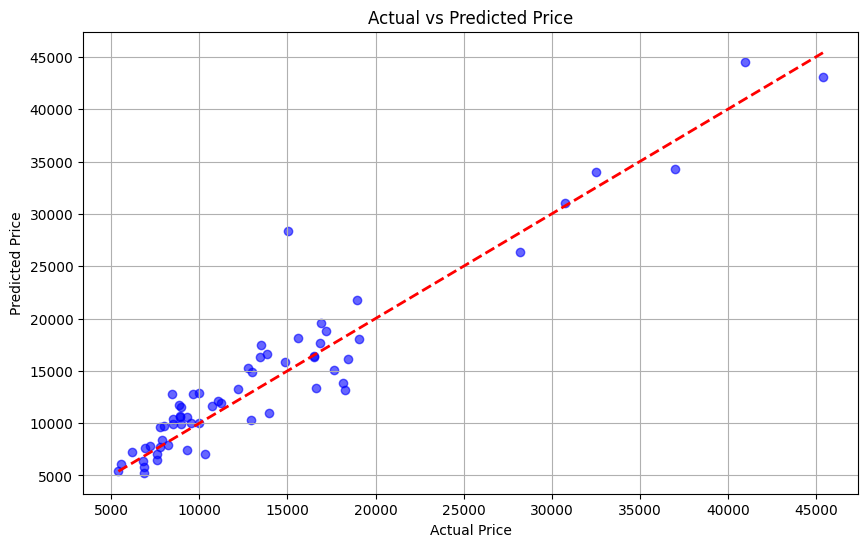

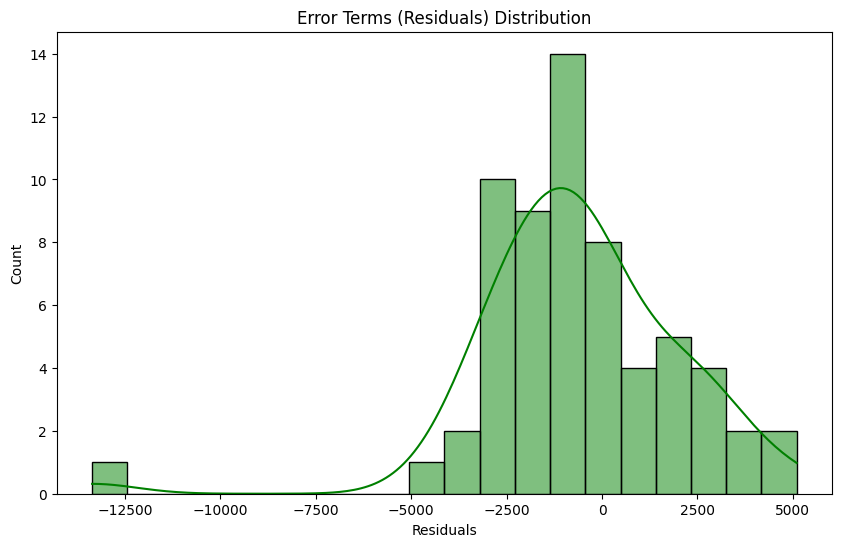

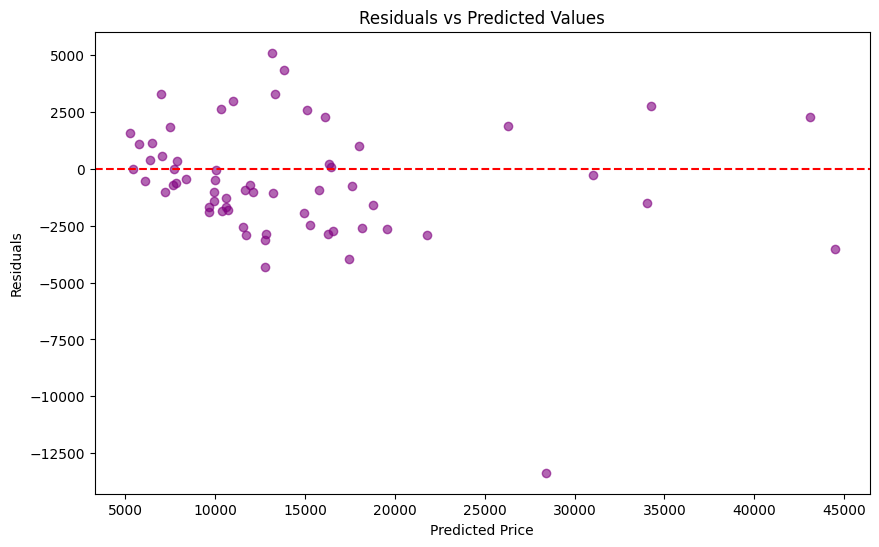

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Previous model training code) ...

# 1. Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

# 2. Residual Distribution Plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=20, color='green')
plt.title('Error Terms (Residuals) Distribution')
plt.xlabel('Residuals')
plt.show()

# 3. Residuals vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

In [9]:
# Select 10 random samples from the test set
sample_indices = X_test_rfe.sample(10, random_state=42).index
X_sample = X_test_rfe.loc[sample_indices]
y_sample_actual = y_test.loc[sample_indices]

# Predict
y_sample_pred = lm.predict(X_sample)

# Create a comparison table
sample_comparison = pd.DataFrame({
    'Actual Price': y_sample_actual,
    'Predicted Price': y_sample_pred,
    'Difference': y_sample_actual - y_sample_pred,
    'Error %': np.abs((y_sample_actual - y_sample_pred) / y_sample_actual) * 100
})

print(sample_comparison.round(2))

     Actual Price  Predicted Price  Difference  Error %
52         6795.0          6404.80      390.20     5.74
123        8921.0         10622.58    -1701.58    19.07
160        7738.0          7734.47        3.53     0.05
28         8921.0         10725.46    -1804.46    20.23
64        11245.0         11953.52     -708.52     6.30
184        7995.0          9687.30    -1692.30    21.17
156        6938.0          7665.38     -727.38    10.48
111       15580.0         18178.68    -2598.68    16.68
101       13499.0         17475.61    -3976.61    29.46
182        7775.0          9671.35    -1896.35    24.39
